<a href="https://colab.research.google.com/github/Kanyz/Tarea_II/blob/main/TAREA_2_ESTAD%C3%8DSTICA_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombres: Isabell Viancha Cuitiva, Camila Alejandra Rondón Aparicio, Ana Gabriela Blanco Cordero y Brayan Steven Valderrama Pabón.


# MODELOS DE REGRESIÓN LINEAL EN LENGUAJE PYTHON

In [4]:
#Paquetes
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from scipy.stats import spearmanr, kendalltau
from mpl_toolkits.mplot3d import Axes3D

In [5]:
from google.colab import files # Para cargar archivos en google colab
uploaded = files.upload()

Saving SB11_20231.TXT to SB11_20231.TXT


In [7]:
datos_icfes = pd.read_csv(                      # Leer el archivo como un CSV
    io.BytesIO(uploaded['SB11_20231.TXT']), # Para cargar el archivo y subirlo directamente a google colab
    delimiter='¬',
    engine='python'                             # Se usa engine='python' para evitar la advertencia de Pandas,ya que el motor por defecto ('c') no soporta este tipo de separador
)
datos_icfes.head() #ver las primeras filas del DataFrame

,ESTU_TIPODOCUMENTO,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,PERIODO,ESTU_CONSECUTIVO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_DEPTO,...,PUNT_INGLES,PERCENTIL_INGLES,DESEMP_INGLES,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,PERCENTIL_ESPECIAL_GLOBAL,ESTU_ESTADOINVESTIGACION
0,TI,COLOMBIA,F,04/11/2005,20231,SB11202310019049,ESTUDIANTE,COLOMBIA,CUNDINAMARCA,25,...,87.0,94.0,B+,422,100.0,67.532814,4.0,4,100.0,PUBLICAR
1,TI,COLOMBIA,M,08/04/2007,20231,SB11202310017318,ESTUDIANTE,COLOMBIA,VALLE,76,...,NaN,NaN,NaN,326,NaN,47.223972,2.0,3,100.0,PUBLICAR
2,TI,COLOMBIA,F,26/05/2006,20231,SB11202310030916,ESTUDIANTE,COLOMBIA,VALLE,76,...,NaN,NaN,NaN,186,NaN,67.695519,4.0,3,40.0,PUBLICAR
3,CC,COLOMBIA,F,24/05/2004,20231,SB11202310074169,ESTUDIANTE,COLOMBIA,VALLE,76,...,58.0,43.0,A2,200,12.0,41.863163,2.0,3,58.0,PUBLICAR
4,TI,COLOMBIA,F,04/05/2005,20231,SB11202310044933,ESTUDIANTE,COLOMBIA,VALLE,76,...,69.0,57.0,B1,263,39.0,51.223795,3.0,3,92.0,PUBLICAR


In [8]:
datos_icfes.info() #Ver el nombre de las columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12704 entries, 0 to 12703
Data columns (total 83 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ESTU_TIPODOCUMENTO             12704 non-null  object 
 1   ESTU_NACIONALIDAD              12704 non-null  object 
 2   ESTU_GENERO                    12704 non-null  object 
 3   ESTU_FECHANACIMIENTO           12704 non-null  object 
 4   PERIODO                        12704 non-null  int64  
 5   ESTU_CONSECUTIVO               12704 non-null  object 
 6   ESTU_ESTUDIANTE                12704 non-null  object 
 7   ESTU_PAIS_RESIDE               12704 non-null  object 
 8   ESTU_DEPTO_RESIDE              12704 non-null  object 
 9   ESTU_COD_RESIDE_DEPTO          12704 non-null  int64  
 10  ESTU_MCPIO_RESIDE              12704 non-null  object 
 11  ESTU_COD_RESIDE_MCPIO          12704 non-null  int64  
 12  ESTU_PRESENTACIONSABADO        12702 non-null 

In [9]:
datos_icfes.describe() #Ver las estadísticas de las columnas numérica

,PERIODO,ESTU_COD_RESIDE_DEPTO,ESTU_COD_RESIDE_MCPIO,COLE_CODIGO_ICFES,COLE_COD_DANE_ESTABLECIMIENTO,SEED_CODIGOMEN,COLE_COD_DANE_SEDE,COLE_COD_MCPIO_UBICACION,COLE_COD_DEPTO_UBICACION,ESTU_COD_MCPIO_PRESENTACION,...,PERCENTIL_SOCIALES_CIUDADANAS,DESEMP_SOCIALES_CIUDADANAS,PUNT_INGLES,PERCENTIL_INGLES,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,PERCENTIL_ESPECIAL_GLOBAL
count,12704.0,12704.000000,12704.000000,12704.000000,1.270400e+04,12704.000000,1.270400e+04,12704.000000,12704.000000,12704.000000,...,12704.00000,12704.000000,12702.000000,12702.000000,12704.000000,12702.000000,11855.000000,11855.000000,12704.000000,11.000000
mean,20231.0,46.861067,46930.803999,137812.243545,3.580633e+11,144.347607,3.580633e+11,47219.970954,47.107761,46800.813996,...,64.00063,2.851464,72.882066,65.866635,316.850362,65.505196,63.008162,3.422522,3.484572,88.000000
std,0.0,31.060190,31076.671884,212074.542023,4.236889e+10,62.767199,4.236889e+10,30787.343950,30.801400,31190.814381,...,24.36030,0.786343,13.992488,22.735517,48.062085,22.852094,7.426674,0.636775,0.531979,19.879638
min,20231.0,5.000000,5001.000000,182.000000,1.765200e+11,5.000000,1.765200e+11,5001.000000,5.000000,5001.000000,...,1.00000,1.000000,26.000000,1.000000,140.000000,1.000000,23.416927,1.000000,2.000000,40.000000
25%,20231.0,11.000000,11001.000000,19497.000000,3.118480e+11,68.000000,3.118480e+11,11001.000000,11.000000,11001.000000,...,47.00000,2.000000,63.000000,50.000000,286.750000,49.000000,58.184055,3.000000,3.000000,92.500000
50%,20231.0,68.000000,68276.000000,55657.000000,3.760010e+11,188.000000,3.760010e+11,68276.000000,68.000000,68001.000000,...,67.00000,3.000000,76.000000,68.000000,323.000000,68.000000,63.989899,3.000000,4.000000,97.000000
75%,20231.0,76.000000,76001.000000,124032.000000,3.760010e+11,188.000000,3.760010e+11,76001.000000,76.000000,76001.000000,...,84.00000,3.000000,82.000000,85.000000,352.000000,85.000000,68.540824,4.000000,4.000000,98.500000
max,20231.0,81.000000,81001.000000,809145.000000,4.768921e+11,272.000000,4.768921e+11,76892.000000,76.000000,81001.000000,...,100.00000,4.000000,100.000000,100.000000,478.000000,100.000000,83.007321,4.000000,4.000000,100.000000


In [10]:
#Eliminación de valores faltantes en el análisis estadístico
icfes_sin_nan = datos_icfes[(~datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
 (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
 (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
 (~datos_icfes['PUNT_C_NATURALES'].isna()) &
 (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
 (~datos_icfes['PUNT_INGLES'].isna())]

In [11]:
#Modelo de Regresión con todas las variables numericas
tabla_regresion = datos_icfes[['ESTU_INSE_INDIVIDUAL','PUNT_LECTURA_CRITICA','PUNT_MATEMATICAS','PUNT_C_NATURALES','PUNT_SOCIALES_CIUDADANAS','PUNT_INGLES']]
tabla_regresion.head(4) #Ver las primeras filas

,ESTU_INSE_INDIVIDUAL,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
0,67.532814,100,83,77,77,87.0
1,47.223972,67,58,68,68,NaN
2,67.695519,37,42,35,35,NaN
3,41.863163,45,41,41,27,58.0


<Axes: >

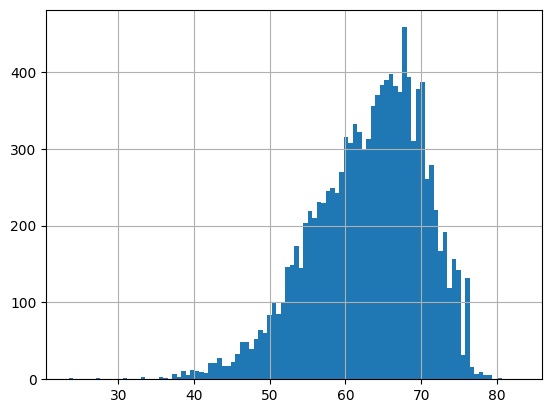

In [12]:
tabla_regresion[("ESTU_INSE_INDIVIDUAL")].hist(bins=100) #Histograma de la variable dependiente

<Axes: >

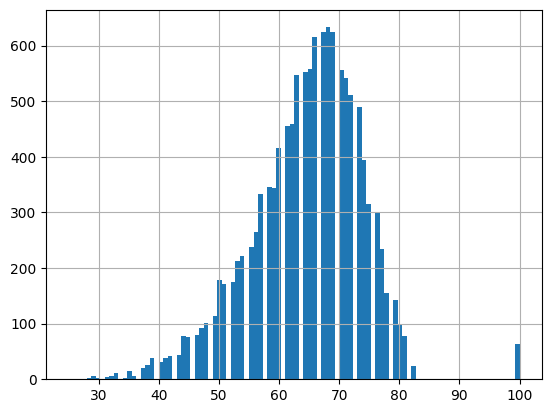

In [13]:
tabla_regresion[("PUNT_LECTURA_CRITICA")].hist(bins=100) #Histograma de la variable explicativa

<Axes: >

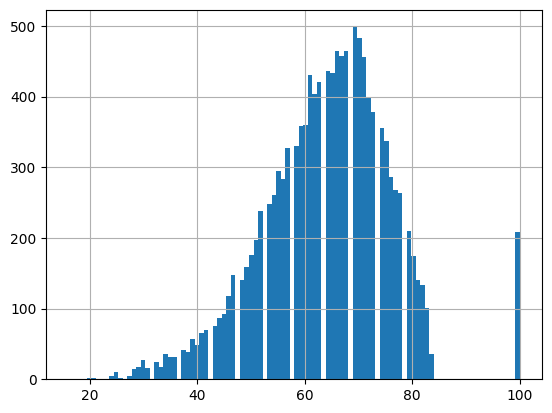

In [14]:
tabla_regresion[("PUNT_MATEMATICAS")].hist(bins=100) #Histograma de la variable explicativa

<Axes: >

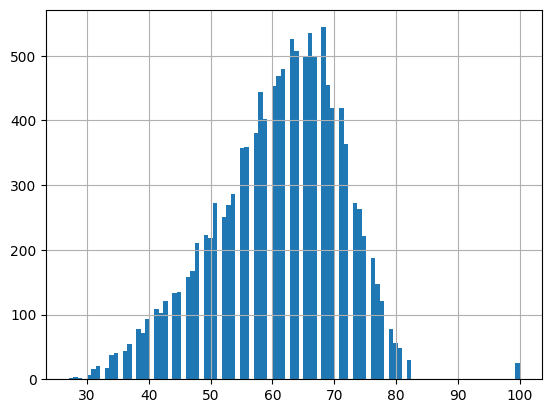

In [15]:
tabla_regresion[("PUNT_C_NATURALES")].hist(bins=100) #Histograma de la variable explicativa

<Axes: >

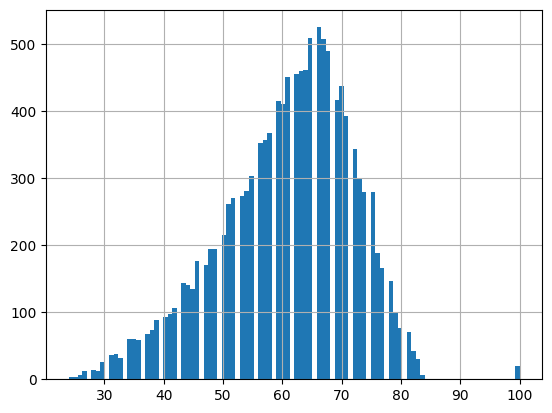

In [16]:
tabla_regresion[("PUNT_SOCIALES_CIUDADANAS")].hist(bins=100) #Histograma de la variable explicativa

<Axes: >

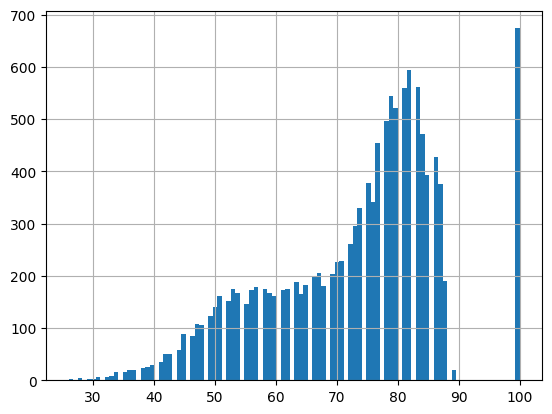

In [17]:
tabla_regresion[("PUNT_INGLES")].hist(bins=100) #Histograma de la variable explicativa

In [18]:
#Selección de datos no representativos para entrenar al modelo de regresión lineal
tabla_regresion1 = tabla_regresion[(tabla_regresion["ESTU_INSE_INDIVIDUAL"]<80) & (tabla_regresion["PUNT_LECTURA_CRITICA"]<90) &
                  (tabla_regresion["PUNT_MATEMATICAS"]<90) & (tabla_regresion["PUNT_C_NATURALES"]<90) & (tabla_regresion["PUNT_SOCIALES_CIUDADANAS"]<90) &
                  (tabla_regresion["PUNT_INGLES"]<90)]

#Visualización de los primeros cinco elementos
tabla_regresion1.head(5)

,ESTU_INSE_INDIVIDUAL,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
3,41.863163,45,41,41,27,58.0
4,51.223795,53,55,41,56,69.0
5,57.690401,63,38,60,59,45.0
6,39.984838,69,60,59,51,50.0
7,50.613232,57,68,74,61,52.0


# Diagrama de dispersición

In [19]:
x = np.array(tabla_regresion1['ESTU_INSE_INDIVIDUAL']).reshape(-1, 1)  #Tipo numpy para una columna
y = tabla_regresion1['PUNT_INGLES']
trainx, testx, trainy, testy = train_test_split(x,y, test_size= 0.2, random_state= 0) #Tomar variables de entrenamiento
modelo_lineal0 = LinearRegression() #Carga de función lineal
regresion0 = modelo_lineal0.fit(trainx,trainy) #Reconocimiento de variable respuesta y explicativas (Datos de entrenamiento)
pred_lineal0 = regresion0.predict(testx)  #Predicción datos de validación

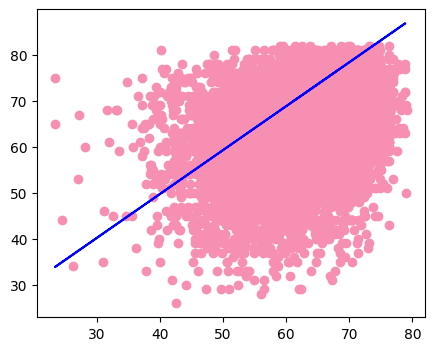

In [20]:
#Elaboración de diagramas de dispersión, reconocer variables explicativas y no explicativas

plt.figure(figsize=(5,4)) #Genera el tamaño de la figura
plt.scatter(tabla_regresion1["ESTU_INSE_INDIVIDUAL"],tabla_regresion1["PUNT_LECTURA_CRITICA"], c="#F78FB3") #Diagrama de dispersión, con
                                                                                                            #tabla_regresion1["PUNT_LECTURA_CRITICA"] → valores del eje X (variable explicativa)
                                                                                                            #tabla_regresion1["ESTU_INSE_INDIVIDUAL"] → valores del eje Y (variable respuesta)
                                                                                                            #con un bello color rosita
plt.plot(testx, pred_lineal0, linestyle = "-", color= "blue")                                               #Recta de regresión
plt.show()                                                                                                  #Mostrar diagrama

A mayores valores del índice socioeconómico individual los puntajes en lectura crítica podrían aumentar ligeramente. Sin embargo, la alta variabilidad indica que los datos no presentante dependencia o es muy débil, por lo que el índice socioeconómico no explica de manera significativa el desempeño en lectura crítica por sí solo.

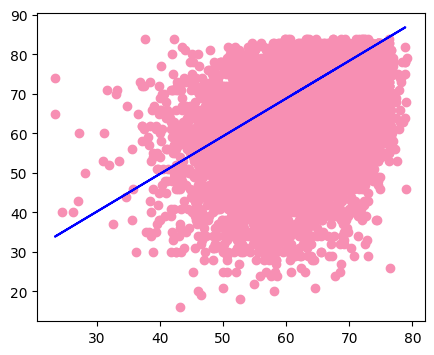

In [21]:
plt.figure(figsize=(5,4)) #Genera el tamaño de la figura
plt.scatter(tabla_regresion1["ESTU_INSE_INDIVIDUAL"],tabla_regresion1["PUNT_MATEMATICAS"], c="#F78FB3") #Diagrama de dispersión, con
                                                                                                        #tabla_regresion1["PUNT_MATEMATICAS"] → valores del eje X (variable explicativa)
                                                                                                        #tabla_regresion1["ESTU_INSE_INDIVIDUAL"] → valores del eje Y (variable respuesta)
                                                                                                        #con un bello color rosita
plt.plot(testx, pred_lineal0, linestyle = "-", color= "blue")                                           #Recta de regresión
plt.show()                                                                                              #Mostrar diagrama

A mayores valores del índice socioeconómico individual los puntajes en matemáticas podrían aumentar ligeramente. Sin embargo, la alta variabilidad indica que los datos no presentante dependencia o es muy débil, por lo que el índice socioeconómico no explica de manera significativa el desempeño en matemáticas por sí solo.

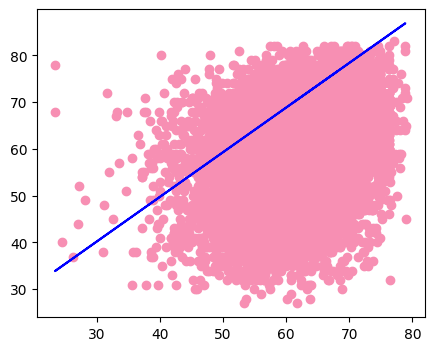

In [22]:
plt.figure(figsize=(5,4)) #Genera el tamaño de la figura
plt.scatter(tabla_regresion1["ESTU_INSE_INDIVIDUAL"],tabla_regresion1["PUNT_C_NATURALES"], c="#F78FB3") #Diagrama de dispersión, con
                                                                                                        #tabla_regresion1["PUNT_C_NATURALES"] → valores del eje X (variable explicativa)
                                                                                                        #tabla_regresion1["ESTU_INSE_INDIVIDUAL"] → valores del eje Y (variable respuesta)
                                                                                                        #con un bello color rosita
plt.plot(testx, pred_lineal0, linestyle = "-", color= "blue")                                           #Recta de regresión
plt.show()                                                                                              #Mostrar diagrama

A mayores valores del índice socioeconómico individual los puntajes en ciencias naturales podrían aumentar ligeramente. Sin embargo, la alta variabilidad indica que los datos no presentante dependencia o es muy débil, por lo que el índice socioeconómico no explica de manera significativa el desempeño en ciencias naturales por sí solo.

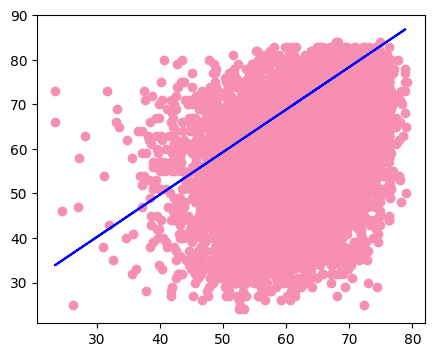

In [23]:
plt.figure(figsize=(5,4)) #Genera el tamaño de la figura
plt.scatter(tabla_regresion1["ESTU_INSE_INDIVIDUAL"],tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"],c="#F78FB3") #Diagrama de dispersión, con
                                                                                                               #tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"] → valores del eje X (variable explicativa)
                                                                                                               #tabla_regresion1["ESTU_INSE_INDIVIDUAL"] → valores del eje Y (variable respuesta)
                                                                                                               #con un bello color rosita
plt.plot(testx, pred_lineal0, linestyle = "-", color= "blue")                                                  #Recta de regresión
plt.show()                                                                                                     #Mostrar el diagrama

A mayores valores del índice socioeconómico individual los puntajes en sociales y competencias ciudadanas podrían aumentar ligeramente. Sin embargo, la alta variabilidad indica que los datos no presentante dependencia o es muy débil, por lo que el índice socioeconómico no explica de manera significativa el desempeño en sociales y competencias ciudadanas por sí solo.

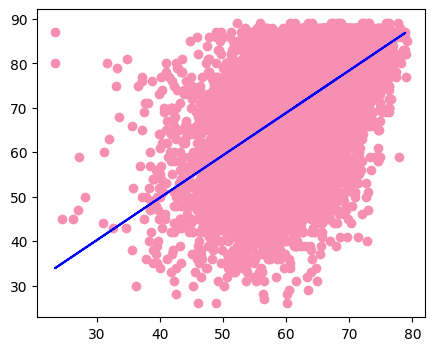

In [24]:
#Diagrama de dispersión junto con recta de regresión:
plt.figure(figsize=(5,4)) #Genera el tamaño de la figura
plt.scatter(tabla_regresion1["ESTU_INSE_INDIVIDUAL"],tabla_regresion1["PUNT_INGLES"],c="#F78FB3") #Diagrama de dispersión, con
                                                                                                  #tabla_regresion1["PUNT_INGLES"] → valores del eje X (variable explicativa)
                                                                                                  #tabla_regresion1["ESTU_INSE_INDIVIDUAL"] → valores del eje Y (variable respuesta)
                                                                                                  #con un bello color rosita
plt.plot(testx, pred_lineal0, linestyle = "-", color= "blue")                                     #Recta de regresión
plt.show()                                                                                        #Mostrar diagrama

A mayores valores del índice socioeconómico individual los puntajes en inglés podrían aumentar ligeramente. Sin embargo, la alta variabilidad indica que los datos no presentante dependencia o es muy débil, por lo que el índice socioeconómico no explica de manera significativa el desempeño en inglés por sí solo.

Para todos los datos sin datos de entrenamiento (Tomando una de las variables como ejemplo):

In [25]:
x0 = np.array(tabla_regresion1['ESTU_INSE_INDIVIDUAL']).reshape(-1, 1) # Variable independiente (X): ESTU_INSE_INDIVIDUAL
y0= tabla_regresion1['PUNT_INGLES'] # Variable dependiente (Y): PUNT_INGLES
modelo_lineal01 = LinearRegression() #Carga de función lineal
regresion01 = modelo_lineal0.fit(x0,y0) #Ajustar el modelo a los datos (Sin entrenamiento)
pred_lineal01 = regresion01.predict(x0) #Valores estimados

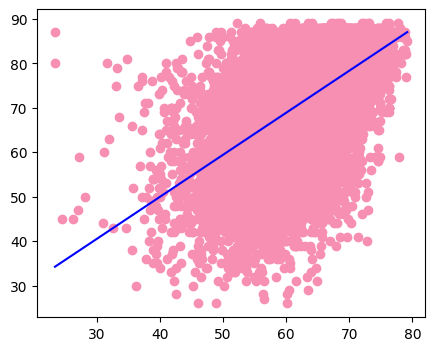

In [26]:
# Ordenar los datos para graficar la recta correctamente (Antes me daba una recta de regresión super exotica)
orden = np.argsort(x0.flatten())

# Crear la figura
plt.figure(figsize=(5,4))

# Gráfica de dispersión (color rosa)
plt.scatter(x0, y0, c="#F78FB3")

# Graficar la recta de regresión (ordenada)
plt.plot(x0.flatten()[orden], pred_lineal01[orden], color="blue")

# Mostrar la gráfica
plt.show()

El diagrama de dispersión entre ESTU_INSE_INDIVIDUAL y PUNT_INGLES muestra una tendencia positiva, aunque con una dispersión considerable de los datos.

Esto indica que existe una relación lineal moderada entre las variables.

# Coeficientes de Correlación

In [31]:
#Puntaje Matemáticas vs Ciencias Naturales
pearson = np.corrcoef(tabla_regresion1['PUNT_MATEMATICAS'], tabla_regresion1['PUNT_C_NATURALES'])[0,1]
spearman, _ = spearmanr(tabla_regresion1['PUNT_MATEMATICAS'], tabla_regresion1['PUNT_C_NATURALES'])
kendall, _ = kendalltau(tabla_regresion1['PUNT_MATEMATICAS'], tabla_regresion1['PUNT_C_NATURALES'])
print("Los coeficientes de correlación de Pearson, Spearman y Kendall son: ", pearson, spearman, kendall, "respectivamente.")

Los coeficientes de correlación de Pearson, Spearman y Kendall son:  0.7946138545136252 0.8010064287971449 0.6201753026476619 respectivamente.


In [32]:
#Puntaje Inglés vs Ciencias Naturales
pearson = np.corrcoef(tabla_regresion1['PUNT_C_NATURALES'], tabla_regresion1['PUNT_INGLES'])[0,1]
spearman, _ = spearmanr(tabla_regresion1['PUNT_C_NATURALES'], tabla_regresion1['PUNT_INGLES'])
kendall, _ = kendalltau(tabla_regresion1['PUNT_C_NATURALES'], tabla_regresion1['PUNT_INGLES'])
print("Los coeficientes de correlación de Pearson, Spearman y Kendall son: ", pearson, spearman, kendall, "respectivamente.")

Los coeficientes de correlación de Pearson, Spearman y Kendall son:  0.6212376103141994 0.6010575722940075 0.4367498186060338 respectivamente.


In [33]:
#Puntaje Ciencias Naturales vs Lectura Crítica
pearson = np.corrcoef(tabla_regresion1['PUNT_C_NATURALES'], tabla_regresion1['PUNT_LECTURA_CRITICA'])[0,1]
spearman, _ = spearmanr(tabla_regresion1['PUNT_C_NATURALES'], tabla_regresion1['PUNT_LECTURA_CRITICA'])
kendall, _ = kendalltau(tabla_regresion1['PUNT_C_NATURALES'], tabla_regresion1['PUNT_LECTURA_CRITICA'])
print("Los coeficientes de correlación de Pearson, Spearman y Kendall son: ", pearson, spearman, kendall, "respectivamente.")

Los coeficientes de correlación de Pearson, Spearman y Kendall son:  0.733914661154661 0.727554571291102 0.5496361444689233 respectivamente.


In [34]:
#Puntaje Sociales y Ciudadanas vs Ciencias Naturales
pearson = np.corrcoef(tabla_regresion1['PUNT_SOCIALES_CIUDADANAS'], tabla_regresion1['PUNT_C_NATURALES'])[0,1]
spearman, _ = spearmanr(tabla_regresion1['PUNT_SOCIALES_CIUDADANAS'], tabla_regresion1['PUNT_C_NATURALES'])
kendall, _ = kendalltau(tabla_regresion1['PUNT_SOCIALES_CIUDADANAS'], tabla_regresion1['PUNT_C_NATURALES'])
print("Los coeficientes de correlación de Pearson, Spearman y Kendall son: ", pearson, spearman, kendall, "respectivamente.")

Los coeficientes de correlación de Pearson, Spearman y Kendall son:  0.7818581966094589 0.776093730941687 0.5947917144276494 respectivamente.


Por lo que podemos evidenciar, entre las 4 variables, la que menos tiene indicios de ser una variable explicativa es inglés. Sin embargo, está en el rango de 0.4 y 0.7 donde es posible que sí sea una variable explicativa. Por último las variables de Matemáticas, Lectura Crítica, y Sociales y Ciudadanía son definitivamente variables explicativas, ya que los coeficientes de pearson y spearman muestran una correlación sustancial y esto muestra que son variables explicativas.



---



In [37]:
modelo_lineal = LinearRegression() #Carga de función lineal
regresion = modelo_lineal.fit(trainX,trainY) #Reconocimiento de variable respuesta y explicativas (Datos de entrenamiento)
pred_lineal = regresion.predict(testX)  #Predicción datos de validación

#Recta de regresión

# Modelo de regresión Lineal Multiple

* Datos de entrenamiento: Datos con los cuales se entrena el modelo, es decir, son aquellos datos con los que se **estiman** los parámetros.


```
Diagrama de dispersión, con variable respuesta
'ESTU_INSE_INDIVIDUAL' y con todas las variables explicativas
'PUNT_LECTURA_CRITICA', 'PUNT_MATEMATICAS', 'PUNT_C_NATURALES',
'PUNT_SOCIALES_CIUDADANAS' y 'PUNT_INGLES'

```
ESTU_INSE_INDIVIDUAL = a1 PUNT_LECTURA_CRITICA + a2 PUNT_MATEMATICAS + a3 PUNT_C_NATURALES + a4 PUNT_SOCIALES_CIUDADANAS + a5 PUNT_INGLES + b + E

E ~ Normal (0, sigma^2)

Generalmente se toman 80% de los datos para de entrenamiento y 20% de validación.

Calculo de las esperanzas

* Datos de validación: Son los datos con los cuales se determina si el modelo implementado tiene un buen ajuste o no.

In [36]:
X = tabla_regresion1.drop("ESTU_INSE_INDIVIDUAL", axis = 1) #Eliminación de la columna correspondiente a la variable respuesta
Y = tabla_regresion1["ESTU_INSE_INDIVIDUAL"] #Define la variable respuesta.
trainX, testX, trainY, testY = train_test_split(X, Y, test_size= 0.2, random_state= 0)  #Identifica datos de entrenamiento y validación
                                                                                        #Tamaño de los datos de validación corresponde a 20%
trainX.head(4) #Visualizar los primeros datos de entrenamiento

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
12545,46,58,55,42,68.0
10887,69,55,58,63,82.0
6215,54,64,56,50,69.0
5182,68,74,62,59,88.0


# Coeficiente de Determinación
¿Qué tan bien se ajustan los datos?

In [38]:
r2_lineal = regresion.score(testX, testY)#Calculo de coeficiente de determinación para datos de validación
r2_lineal

0.2962348737142402

Determinar el coeficiente de determinación con la particularidad de ir elimnado variables de los datos de entrenamiento (Probar con cada uno).



---
"PUNT_LECT_CRITICA"


In [39]:
X1 = tabla_regresion1[['PUNT_MATEMATICAS','PUNT_C_NATURALES','PUNT_SOCIALES_CIUDADANAS','PUNT_INGLES']] #Eliminación de la columna correspondiente a la variable respuesta
Y1 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"] #Define la variable respuesta.
train1X, test1X, train1Y, test1Y = train_test_split(X1, Y1, test_size= 0.2, random_state= 0)  #Identifica datos de entrenamiento y validación
                                                                                        #Tamaño de los datos de validación corresponde a 20%
train1X.head(4) #Visualizar los primeros datos de entrenamiento

,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
12545,58,55,42,68.0
10887,55,58,63,82.0
6215,64,56,50,69.0
5182,74,62,59,88.0


Probamos la regresión lineal:

In [40]:
modelo_lineal1 = LinearRegression() #Carga de función lineal
regresion1 = modelo_lineal.fit(train1X,train1Y) #Reconocimiento de variable respuesta y explicativas (Datos de entrenamiento)
pred_lineal1 = regresion1.predict(test1X)  #Predicción datos de validación
r2_lineal1 = regresion.score(test1X, test1Y)#Calculo de coeficiente de determinación para datos de validación
r2_lineal1

0.2947540211982348

Comparando el coeficiente de determinación sin tomar como variable explicativa 'PUNT_LECTURA_CRITICA' y tomando el coeficiente de determinación con 'PUNT_LECTURA_CRITICA' se observa que el coeficiente de determinación con 'PUNT_LECTURA_CRITICA' es de 0.2962348737142402, además se observa que el coeficiente de determinación sin 'PUNT_LECTURA_CRITICA' es de 0.2947540211982348, quiere decir que 'PUNT_LECTURA_CRITICA' es explicativa.



---

'PUNT_MATEMATICAS'

In [41]:
X2 = tabla_regresion1[['PUNT_LECTURA_CRITICA' ,'PUNT_C_NATURALES','PUNT_SOCIALES_CIUDADANAS','PUNT_INGLES']] #Eliminación de la columna correspondiente a la variable respuesta
Y2 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"] #Define la variable respuesta.
train2X, test2X, train2Y, test2Y = train_test_split(X2, Y2, test_size= 0.2, random_state= 0)  #Identifica datos de entrenamiento y validación
                                                                                        #Tamaño de los datos de validación corresponde a 20%
train2X.head(4) #Visualizar los primeros datos de entrenamiento

,PUNT_LECTURA_CRITICA,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
12545,46,55,42,68.0
10887,69,58,63,82.0
6215,54,56,50,69.0
5182,68,62,59,88.0


In [42]:
modelo_lineal2 = LinearRegression() #Carga de función lineal
regresion2 = modelo_lineal.fit(train2X,train2Y) #Reconocimiento de variable respuesta y explicativas (Datos de entrenamiento)
pred_lineal2 = regresion2.predict(test2X)  #Predicción datos de validación
r2_lineal2 = regresion.score(test2X, test2Y)#Calculo de coeficiente de determinación para datos de validación
r2_lineal2

0.29483912553842895

Comparando el coeficiente de determinación sin tomar como variable explicativa 'PUNT_MATEMATICAS' y tomando el coeficiente de determinación con 'PUNT_MATEMATICAS' se observa que el coeficiente de determinación con 'PUNT_MATEMATICAS' es de 0.2962348737142402, además se observa que el coeficiente de determinación sin 'PUNT_MATEMATICAS' es de 0.29483912553842895
, quiere decir que 'PUNT_MATEMATICAS' es explicativa.



---

'PUNT_C_NATURALES'

In [43]:
X3 = tabla_regresion1[['PUNT_LECTURA_CRITICA','PUNT_MATEMATICAS','PUNT_SOCIALES_CIUDADANAS','PUNT_INGLES']] #Eliminación de la columna correspondiente a la variable respuesta
Y3 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"] #Define la variable respuesta.
train3X, test3X, train3Y, test3Y = train_test_split(X3, Y3, test_size= 0.2, random_state= 0)  #Identifica datos de entrenamiento y validación
                                                                                        #Tamaño de los datos de validación corresponde a 20%
train3X.head(4) #Visualizar los primeros datos de entrenamiento

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
12545,46,58,42,68.0
10887,69,55,63,82.0
6215,54,64,50,69.0
5182,68,74,59,88.0


In [44]:
modelo_lineal3 = LinearRegression() #Carga de función lineal
regresion3 = modelo_lineal.fit(train3X,train3Y) #Reconocimiento de variable respuesta y explicativas (Datos de entrenamiento)
pred_lineal3 = regresion3.predict(test3X)  #Predicción datos de validación
r2_lineal3 = regresion.score(test3X, test3Y)#Calculo de coeficiente de determinación para datos de validación
r2_lineal3

0.2959371782929858

Comparando el coeficiente de determinación sin tomar como variable explicativa 'PUNT_C_NATURALES' y tomando el coeficiente de determinación con 'PUNT_C_NATURALES' se observa que el coeficiente de determinación con 'PUNT_C_NATURALES' es de 0.2962348737142402, además se observa que el coeficiente de determinación sin 'PUNT_C_NATURALES' es de 0.2959371782929858, quiere decir que 'PUNT_C_NATURALES' es explicativa.



---

'PUNT_SOCIALES_CIUDADANAS'

In [45]:
X4 = tabla_regresion1[['PUNT_LECTURA_CRITICA','PUNT_MATEMATICAS','PUNT_C_NATURALES','PUNT_INGLES']] #Eliminación de la columna correspondiente a la variable respuesta
Y4 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"] #Define la variable respuesta.
train4X, test4X, train4Y, test4Y = train_test_split(X4, Y4, test_size= 0.2, random_state= 0)  #Identifica datos de entrenamiento y validación
                                                                                        #Tamaño de los datos de validación corresponde a 20%
train4X.head(4) #Visualizar los primeros datos de entrenamiento

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_INGLES
12545,46,58,55,68.0
10887,69,55,58,82.0
6215,54,64,56,69.0
5182,68,74,62,88.0


In [46]:
modelo_lineal4 = LinearRegression() #Carga de función lineal
regresion4 = modelo_lineal.fit(train4X,train4Y) #Reconocimiento de variable respuesta y explicativas (Datos de entrenamiento)
pred_lineal4 = regresion4.predict(test4X)  #Predicción datos de validación
r2_lineal4 = regresion.score(test4X, test4Y)#Calculo de coeficiente de determinación para datos de validación
r2_lineal4

0.2961694957558495

Comparando el coeficiente de determinación sin tomar como variable explicativa 'PUNT_SOCIALES_CIUDADANAS' y tomando el coeficiente de determinación con 'PUNT_SOCIALES_CIUDADANAS' se observa que el coeficiente de determinación con 'PUNT_SOCIALES_CIUDADANAS' es de 0.2962348737142402, además se observa que el coeficiente de determinación sin 'PUNT_SOCIALES_CIUDADANAS' es de 0.2961694957558495.
Dado que la diferencia es mínima, se concluye que 'PUNT_SOCIALES_CIUDADANAS' no es una variable explicativa, ya que su aporte al modelo es prácticamente nulo.



---

'PUNT_INGLES'

In [47]:
X5 = tabla_regresion1[['PUNT_LECTURA_CRITICA','PUNT_MATEMATICAS','PUNT_SOCIALES_CIUDADANAS','PUNT_C_NATURALES']] #Eliminación de la columna correspondiente a la variable respuesta
Y5 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"] #Define la variable respuesta.
train5X, test5X, train5Y, test5Y = train_test_split(X5, Y5, test_size= 0.2, random_state= 0)  #Identifica datos de entrenamiento y validación
                                                                                        #Tamaño de los datos de validación corresponde a 20%
train5X.head(4) #Visualizar los primeros datos de entrenamiento

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES
12545,46,58,42,55
10887,69,55,63,58
6215,54,64,50,56
5182,68,74,59,62


In [48]:
modelo_lineal5 = LinearRegression() #Carga de función lineal
regresion5 = modelo_lineal.fit(train5X,train5Y) #Reconocimiento de variable respuesta y explicativas (Datos de entrenamiento)
pred_lineal5 = regresion5.predict(test5X)  #Predicción datos de validación
r2_lineal5 = regresion.score(test5X, test5Y)#Calculo de coeficiente de determinación para datos de validación
r2_lineal5

0.13362998486245814

Comparando el coeficiente de determinación sin tomar como variable explicativa 'PUNT_INGLES' y tomando el coeficiente de determinación con 'PUNT_INGLES' se observa que el coeficiente de determinación con 'PUNT_INGLES' es de 0.2962348737142402, además se observa que el coeficiente de determinación sin 'PUNT_INGLES' es de 0.13362998486245814, Se evidencia una disminución significativa, por lo que se concluye que 'PUNT_INGLES' es la variable más explicativa del modelo.

En conclusión, la variable 'PUNT_INGLES' es la más influyente en el modelo, le sigue 'PUNT_LECTURA_CRITICA' mientras que 'PUNT_SOCIALES_CIUDADANAS' no aporta significativamente a la explicación de la variable respuesta. Las demás variables representan similitud.


En el gráfico  se observa que los puntos de entrenamiento (azul) y prueba (morado) se dispersan ampliamente alrededor del plano de regresión ajustado con inglés y matemáticas. Esto indica que el modelo lineal con estas dos variables no logra explicar adecuadamente la variabilidad del INSE, lo cual coincide con la alta dispersión vista en los diagramas simples.

# Diagrama con el plano de dispersión

In [49]:
XY, Z = tabla_regresion1[['PUNT_INGLES', 'PUNT_LECTURA_CRITICA']], tabla_regresion1['ESTU_INSE_INDIVIDUAL'] #Eliminación de la columna correspondiente a la variable respuesta
trainXY, testXY, trainZ, testZ = train_test_split(XY, Z, test_size=0.2, random_state=0) #Identifica datos de entrenamiento y validación
                                                                                      #Tamaño de los datos de validación corresponde a 20%
trainXY.head(4)                                                                       #Visualizar los primeros datos de entrenamiento

,PUNT_INGLES,PUNT_LECTURA_CRITICA
12545,68.0,46
10887,82.0,69
6215,69.0,54
5182,88.0,68


In [50]:
#Implementación de modelo de regresión lineal múltiple

modelo1 = LinearRegression()
modelo1.fit(trainXY, trainZ) #Entrenamiento del modelo

LinearRegression()

In [51]:
#Predicción del modelo
modelo1.score(testXY, testZ)

0.29529055571088336

Comparado con r2_lineal (0.2962348737142402) observamos que no cambia mucho su valor a pesar de usar sólo dos variables (Uso de las más explicativas)

In [52]:
#Determinar los coeficientes del modelo
array = modelo1.coef_ #Determinar los estimadores del modelo de regresión
array

array([ 0.33277288, -0.01765587])



*   Intercepto: 0.33277288
*   Pendiente: -0.01765587

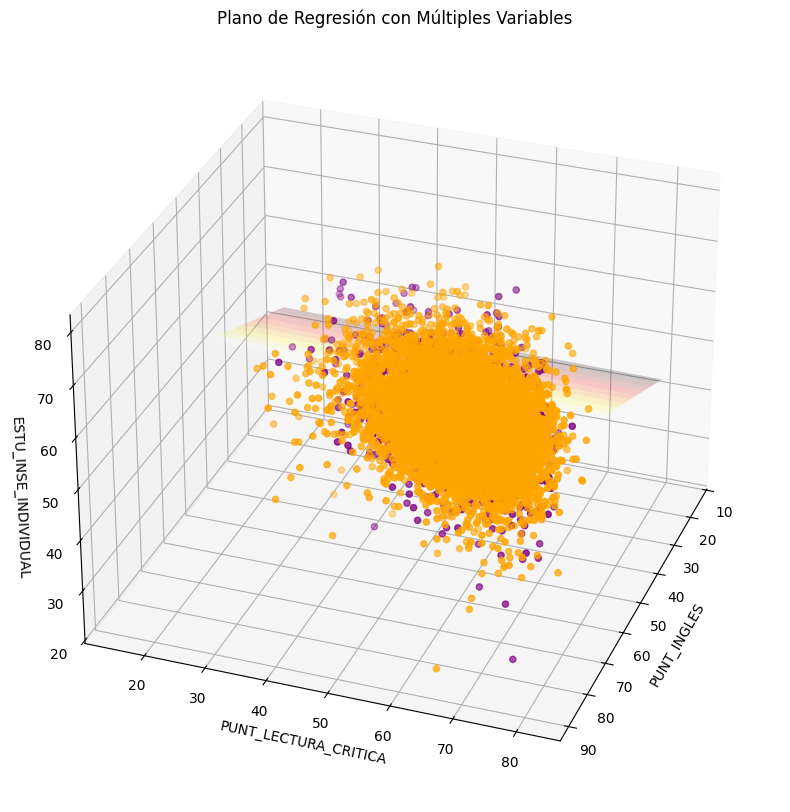

In [53]:
#Creación de malla
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
xx, yy = np.meshgrid(np.linspace(15, 50, num=10), np.linspace(15, 80, num=10))
plano_reg = array[0]*xx + array[1]*yy + modelo1.intercept_   #Regresión lineal múltiple con los parámetros estimados

#Dibujar la superficie del plano de regresión
ax.plot_surface(xx, yy, plano_reg, alpha= 0.2, cmap='hot')

#Puntos de los datos de entrenamiento
ax.scatter(trainXY['PUNT_INGLES'], trainXY['PUNT_LECTURA_CRITICA'], trainZ, c='orange', s=20)

#Puntos de los datos de validación
ax.scatter(testXY['PUNT_INGLES'], testXY['PUNT_LECTURA_CRITICA'], testZ, c='purple', s=20)

#Visualización del gráfico
ax.view_init(elev=30, azim=20)

#Nombre de ejes
ax.set_xlabel('PUNT_INGLES')
ax.set_ylabel('PUNT_LECTURA_CRITICA')
ax.set_zlabel('ESTU_INSE_INDIVIDUAL')
ax.set_title('Plano de Regresión con Múltiples Variables')
plt.show()

Como el coeficiente de determinación nos dio aproximadamente 29% debemos recordar que para tener un buen coeficiente de determinación debe ser superior al 80%.
Hacemos uso de una red neuronal multicapa.

In [54]:
mlp_reg = MLPRegressor(hidden_layer_sizes=(10, 10, 10, 10, 10, 10, 10, 10, 10, 10),
                       max_iter=500, activation= 'relu',
                       solver= 'adam', learning_rate= 'invscaling') #10 capitas de diez nodos

mlp_reg.fit(trainX, trainY) #Entrenamiento del modelo


MLPRegressor(hidden_layer_sizes=(10, 10, 10, 10, 10, 10, 10, 10, 10, 10),
             learning_rate='invscaling', max_iter=500)

In [55]:
#Determinar el coeficiente de correlación
mlp_reg.score(testX, testY)

0.2840273098460254

No ofrece un mejor ajuste, se espera que al agregar muchas más capas pueda ofrecer un modelo con mayor ajuste.
Para hacer una predicción de los valores no observados, se determina un valor al cual se le quiera hacer la predicción.

In [56]:
X.head(4) #Visualización de los primeros 4 datos de la variable X

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
3,45,41,41,27,58.0
4,53,55,41,56,69.0
5,63,38,60,59,45.0
6,69,60,59,51,50.0


#Diagrama de Dispersión lineal Multiple

In [57]:
# =============================================================================
# MODELO DE REGRESIÓN LINEAL MÚLTIPLE (con las 5 variables explicativas)
# =============================================================================

# Variables explicativas (las 5 puntajes)
X = icfes_sin_nan[['PUNT_LECTURA_CRITICA',
                    'PUNT_MATEMATICAS',
                    'PUNT_C_NATURALES',
                    'PUNT_SOCIALES_CIUDADANAS',
                    'PUNT_INGLES']]

# Variable respuesta
Y = icfes_sin_nan['ESTU_INSE_INDIVIDUAL']

# División 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
modelo_lineal_multiple = LinearRegression()
modelo_lineal_multiple.fit(X_train, y_train)

# Mostrar resultados
print("=== MODELO DE REGRESIÓN LINEAL MÚLTIPLE ===")
print(f"Intercepto: {modelo_lineal_multiple.intercept_:.4f}")
print("\nCoeficientes:")
for var, coef in zip(X.columns, modelo_lineal_multiple.coef_):
    print(f"  {var}: {coef:.4f}")

=== MODELO DE REGRESIÓN LINEAL MÚLTIPLE ===
Intercepto: 41.6184

Coeficientes:
  PUNT_LECTURA_CRITICA: -0.0305
  PUNT_MATEMATICAS: 0.0459
  PUNT_C_NATURALES: -0.0058
  PUNT_SOCIALES_CIUDADANAS: 0.0056
  PUNT_INGLES: 0.2801




El coeficiente de mayor magnitud es el de **PUNT_INGLES (0.3229)**, lo que indica que el puntaje de inglés es la variable con mayor influencia positiva sobre el índice socioeconómico individual. Las demás variables presentan coeficientes cercanos a cero, lo que sugiere que su aporte al modelo es mínimo.

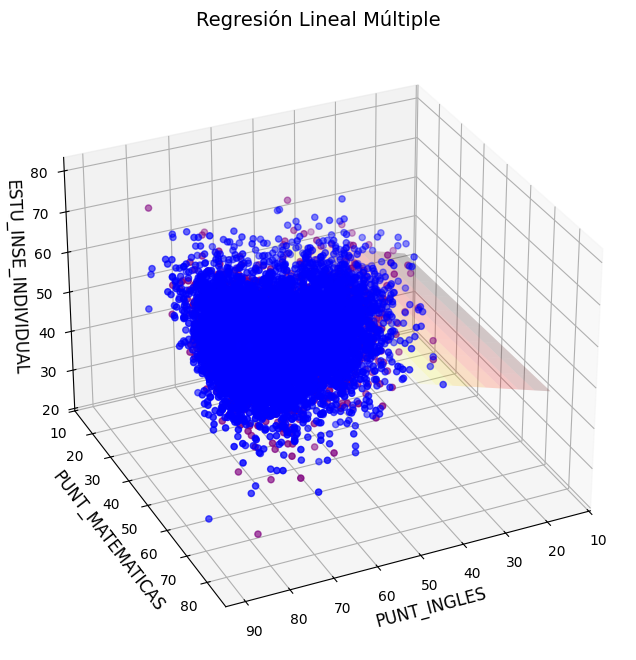

In [58]:
#  Seleccionar variables explicativas, se escogieron las dos con coef positivos para hacer el grafico, pero
# este se puede hacer con cualesquiera 2 variaples explicativas(las que irán en X e Y del plano)
#    y la variable respuesta (Z)
XY = tabla_regresion1[['PUNT_INGLES', 'PUNT_MATEMATICAS']]
Z = tabla_regresion1['ESTU_INSE_INDIVIDUAL']

# Dividir en entrenamiento (80%) y prueba (20%)
trainXY, testXY, trainZ, testZ = train_test_split(XY, Z, test_size=0.2, random_state=0)

# Crear y entrenar el modelo de regresión lineal con las dos variables explicativas
modelo_3d = LinearRegression()
modelo_3d.fit(trainXY, trainZ)

# Obtener los coeficientes (pendientes para cada eje X e Y)
coefs = modelo_3d.coef_  # array con [coef_ingles, coef_matematicas]
intercept = modelo_3d.intercept_

# Crear la malla para el plano
xx, yy = np.meshgrid(
    np.linspace(15, 50, num=10),   # rango de PUNT_INGLES (mínimo y máximo aproximado)
    np.linspace(15, 80, num=10)    # rango de PUNT_MATEMATICAS
)
# Ecuación del plano: Z = coef_ingles * X + coef_matematicas * Y + intercept
plano = coefs[0] * xx + coefs[1] * yy + intercept

# Crear la figura
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujar el plano de regresión (superficie)
ax.plot_surface(xx, yy, plano, alpha=0.2, cmap='hot')

# Dibujar puntos de entrenamiento (azul)
ax.scatter(trainXY['PUNT_INGLES'], trainXY['PUNT_MATEMATICAS'], trainZ,
           c='blue', s=20, label='Entrenamiento')

# Dibujar puntos de prueba (morado)
ax.scatter(testXY['PUNT_INGLES'], testXY['PUNT_MATEMATICAS'], testZ,
           c='purple', s=20, label='Prueba')

# Configurar ángulo de vista
ax.view_init(elev=30, azim=65)

# Etiquetas de los ejes
ax.set_xlabel('PUNT_INGLES', fontsize=12)
ax.set_ylabel('PUNT_MATEMATICAS', fontsize=12)
ax.set_zlabel('ESTU_INSE_INDIVIDUAL', fontsize=12)
ax.set_title('Regresión Lineal Múltiple', fontsize=14)

# Mostrar gráfico
plt.show()

# Modelo de Red Neuronal

In [59]:
icfes_connan = datos_icfes[(datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
(~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
(~datos_icfes['PUNT_MATEMATICAS'].isna()) &
(~datos_icfes['PUNT_C_NATURALES'].isna()) &
(~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
(~datos_icfes['PUNT_INGLES'].isna())]
icfes_connan.head(5)

,ESTU_TIPODOCUMENTO,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,PERIODO,ESTU_CONSECUTIVO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_DEPTO,...,PUNT_INGLES,PERCENTIL_INGLES,DESEMP_INGLES,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,PERCENTIL_ESPECIAL_GLOBAL,ESTU_ESTADOINVESTIGACION
35,TI,COLOMBIA,F,25/10/2005,20231,SB11202310012523,ESTUDIANTE,COLOMBIA,VALLE,76,...,52.0,33.0,A1,293,53.0,NaN,NaN,2,NaN,PUBLICAR
63,TI,COLOMBIA,M,03/05/2006,20231,SB11202310004061,ESTUDIANTE,COLOMBIA,VALLE,76,...,57.0,42.0,A1,318,66.0,NaN,NaN,3,NaN,PUBLICAR
84,TI,COLOMBIA,F,24/09/2003,20231,SB11202310038767,ESTUDIANTE,COLOMBIA,VALLE,76,...,46.0,23.0,A-,218,20.0,NaN,NaN,3,NaN,PUBLICAR
183,TI,COLOMBIA,M,22/12/2005,20231,SB11202310005059,ESTUDIANTE,COLOMBIA,VALLE,76,...,55.0,39.0,A1,280,46.0,NaN,NaN,3,NaN,PUBLICAR
201,TI,COLOMBIA,M,11/11/2005,20231,SB11202310028363,ESTUDIANTE,COLOMBIA,CAUCA,19,...,50.0,29.0,A1,259,37.0,NaN,NaN,4,NaN,PUBLICAR


In [60]:
red = MLPRegressor(hidden_layer_sizes=(100,100,100,100, 100, 100), max_iter = 500,
                   activation = 'relu', solver = 'adam',  learning_rate = 'invscaling') #Red

red.fit(trainX, trainY) #Entrenar el modelo de la red

MLPRegressor(hidden_layer_sizes=(100, 100, 100, 100, 100, 100),
             learning_rate='invscaling', max_iter=500)

In [64]:
# Inicializa el modelo de regresión lineal múltiple
modelo_lineal = LinearRegression()
# Ajusta (entrena) el modelo utilizando los datos de entrenamiento
regresion = modelo_lineal.fit(trainX, trainY)

r2_r1 = r2_score(testY, modelo_lineal.predict(testX))
r2_mlp = r2_score(testY, red.predict(testX))
print(r2_r1)
print(r2_mlp)

#Se elige el mejor modelo a utilizar
if r2_mlp > r2_r1:
  modelo = red
else :
  modelo = modelo_lineal

#Por último, después de elegir el mejor modelo, se reemplazan los valores donde faltaban los valores de 'ESTU_INSE_INDIVIDUAL' con las predicciones de nuestra red
datos_icfes.loc[icfes_connan.index, 'ESTU_INSE_INDIVIDUAL'] = red.predict(icfes_connan[['PUNT_LECTURA_CRITICA','PUNT_MATEMATICAS','PUNT_C_NATURALES','PUNT_SOCIALES_CIUDADANAS','PUNT_INGLES']])

0.2962348737142402
0.23136001214691604


# Predicciones de Interés

Las predicciones realizadas permiten evidenciar cómo diferentes combinaciones de desempeño en diferentes componentes de la prueba ICFES influyen en la estimación del nivel socioeconómico.

Calificación alta en cada componente de la prueba. PUNT_LECTURA_CRITICA	PUNT_MATEMATICAS	PUNT_C_NATURALES	PUNT_SOCIALES_CIUDADANAS y	PUNT_INGLES respectivamente:  

In [62]:
no_obs = np.array([[70, 72, 68, 80, 90]]) #Selección de variables a estudiar
print('Se espera que para un estudiante con las características dadas, se estima que el valor de ESTU_INSE_INDIVIDUAL es', mlp_reg.predict(no_obs),'bajo el perceptón multicapa y', modelo_lineal.predict(no_obs), 'bajo el modelo de regresión lineal multiple')


Se espera que para un estudiante con las características dadas, se estima que el valor de ESTU_INSE_INDIVIDUAL es [69.25300388] bajo el perceptón multicapa y [68.80623061] bajo el modelo de regresión lineal multiple


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Calificación alta en el componente de la prueba PUNT_INGLES y calificación baja en PUNT_LECTURA_CRITICA con las demás variables constantes:

In [63]:
no_obs = np.array([[30, 60, 62, 81, 80]]) #Selección de variables a estudiar
print('Se espera que para un estudiante con las características dadas, se estima que el valor de ESTU_INSE_INDIVIDUAL es', mlp_reg.predict(no_obs),'bajo el perceptón multicapa y', modelo_lineal.predict(no_obs), 'bajo el modelo de regresión lineal multiple')


Se espera que para un estudiante con las características dadas, se estima que el valor de ESTU_INSE_INDIVIDUAL es [72.7298555] bajo el perceptón multicapa y [66.80543814] bajo el modelo de regresión lineal multiple


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Calificación alta en el componente de la prueba PUNT_INGLES, calificación alta en PUNT_C_NATURALES y calificación baja en PUNT_SOCIALES_CIUDADANAS con las demás variables constantes:


In [65]:
no_obs = np.array([[50, 53, 33, 87, 95]]) #Selección de variables a estudiar
print('Se espera que para un estudiante con las características dadas, se estima que el valor de ESTU_INSE_INDIVIDUAL es', mlp_reg.predict(no_obs),'bajo el perceptón multicapa y', modelo_lineal.predict(no_obs), 'bajo el modelo de regresión lineal multiple')

Se espera que para un estudiante con las características dadas, se estima que el valor de ESTU_INSE_INDIVIDUAL es [77.81427696] bajo el perceptón multicapa y [70.81690635] bajo el modelo de regresión lineal multiple


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Las predicciones muestran que un mayor puntaje obtenido en las pruebas ICFES se asocia con valores más altos de ESTU_INSE_INDIVIDUAL, destacándose el puntaje en inglés como una variable influyente. Además, el modelo de perceptón presenta estimaciones ligeramente mayores al modelo de regresión lineal multiple, lo que sugiere una mejor captura de relaciones entre las variables.

Completar valores faltantes:

In [66]:
#Selección de datos no representativos para entrenar al modelo de regresión lineal
tabla_regresion00 = tabla_regresion[(tabla_regresion["ESTU_INSE_INDIVIDUAL"]>80) & (tabla_regresion["PUNT_LECTURA_CRITICA"]<90) &
                  (tabla_regresion["PUNT_MATEMATICAS"]<90) & (tabla_regresion["PUNT_C_NATURALES"]<90) & (tabla_regresion["PUNT_SOCIALES_CIUDADANAS"]<90) &
                  (tabla_regresion["PUNT_INGLES"]<90)]

#Visualización de los primeros cuarenta elementos
tabla_regresion00.head(40)

,ESTU_INSE_INDIVIDUAL,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
1198,83.007321,75,64,71,59,83.0
8910,80.453570,61,68,67,50,78.0
10650,80.453570,68,68,58,66,87.0


Sólo existen 3 individuos que cumplen con esta condición para los cuales no se conoce su ESTU_INSE_INDIVIDUAL pero sí se conocen las otras variables.


In [67]:
X_no_ob = tabla_regresion00.drop("ESTU_INSE_INDIVIDUAL", axis = 1) #Seleccionar las variables sin ESTU_INSE_INDIVIDUAL
X_no_ob

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
1198,75,64,71,59,83.0
8910,61,68,67,50,78.0
10650,68,68,58,66,87.0


In [68]:
#Determinar la predicción de los datos:
mlp_reg.predict(X_no_ob)

array([65.18244892, 64.60754514, 67.1339507 ])

In [69]:
tabla_regresion00["ESTU_INSE_INDIVIDUAL"] = mlp_reg.predict(X_no_ob)
tabla_regresion00

/tmp/ipykernel_4840/1525511433.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla_regresion00["ESTU_INSE_INDIVIDUAL"] = mlp_reg.predict(X_no_ob)


,ESTU_INSE_INDIVIDUAL,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
1198,65.182449,75,64,71,59,83.0
8910,64.607545,61,68,67,50,78.0
10650,67.133951,68,68,58,66,87.0


Obtuvimos los valores imputados que se pueden usar posteriormente para la implementación de un nuevo análisis estadístico.A partir de esto, se comparan los resultados con los criterios de admisión de la Universidad Industrial de Santander.

# Puntajes de corte de admisión de la UIS para las carreras de interés
----
Para el análisis se tomaron como referencia los criterios de selección de la Universidad Industrial de Santander, considerando los porcentajes en cada área del ICFES según el programa académico. Asimismo, se utilizaron los puntajes ponderados mínimos y máximos de admisión como base de comparación.

Las carreras de interés seleccionadas fueron Matemáticas, Fisioterapia y Derecho, debido a que presentan diferentes perfiles de evaluación en las áreas analizadas, lo que permite realizar una comparación más completa del comportamiento de los aspirantes.

Los criterios de selección se basan en la ponderación de las áreas evaluadas en el examen ICFES, asignando a cada una un peso específico según el programa académico, de acuerdo con el Registro Calificado (Resolución del MEN) de cada programa.Adicionalmente, se considera un puntaje mínimo por área, generalmente igual o superior a 31 puntos, como requisito básico para el proceso de admisión.En Matemáticas, el área de matemáticas tiene un peso del 50%, lectura crítica 20% y las demás áreas 10% cada una. En Fisioterapia, ciencias naturales tiene un 40%, lectura crítica 20%, matemáticas y sociales 15% cada una, e inglés 10%. En Derecho, lectura crítica representa el 40%, matemáticas y sociales 20% cada una, y ciencias naturales e inglés 10%.

A partir de estas ponderaciones se calcula un puntaje ponderado para cada estudiante, el cual permite compararlo con los puntajes mínimos y máximos de admisión establecidos para cada programa, siendo estos 54,60 y 68,60 para Matemáticas; 67,85 y 76,85 para Fisioterapia; y 67,10 y 74,50 para Derecho.

Los puntajes ponderados utilizados fueron tomados de la página oficial de la Universidad Industrial de Santander (https://inscripciones.uis.edu.co/criterios-seleccion-pregrado/) y corresponden al rango máximo y mínimo observado en los procesos de admisión entre noviembre de 2017 y noviembre de 2025. Por esta razón, los resultados obtenidos en este análisis deben interpretarse como una aproximación al compararlos con la base de datos del ICFES del periodo 2023-1.

In [70]:
icfes_sin_nan = datos_icfes[
    (~datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
    (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
    (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
    (~datos_icfes['PUNT_C_NATURALES'].isna()) &
    (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
    (~datos_icfes['PUNT_INGLES'].isna())
].copy() # Se crea una copia del DataFrame sin valores faltantes para evitar problemas
          # de modificación sobre vistas (SettingWithCopyWarning)

In [71]:
# Filtro de puntaje mínimo por área (criterio de admisión UIS)
icfes_sin_nan = icfes_sin_nan[
    (icfes_sin_nan['PUNT_MATEMATICAS'] >= 31) &
    (icfes_sin_nan['PUNT_LECTURA_CRITICA'] >= 31) &
    (icfes_sin_nan['PUNT_C_NATURALES'] >= 31) &
    (icfes_sin_nan['PUNT_SOCIALES_CIUDADANAS'] >= 31) &
    (icfes_sin_nan['PUNT_INGLES'] >= 31)
]

In [72]:
#Matematicas
icfes_sin_nan['POND_MAT'] = (
    0.50 * icfes_sin_nan['PUNT_MATEMATICAS'] +
    0.20 * icfes_sin_nan['PUNT_LECTURA_CRITICA'] +
    0.10 * icfes_sin_nan['PUNT_C_NATURALES'] +
    0.10 * icfes_sin_nan['PUNT_SOCIALES_CIUDADANAS'] +
    0.10 * icfes_sin_nan['PUNT_INGLES']
)
#Fisioterapia
icfes_sin_nan['POND_FISIO'] = (
    0.40 * icfes_sin_nan['PUNT_C_NATURALES'] +
    0.20 * icfes_sin_nan['PUNT_LECTURA_CRITICA'] +
    0.15 * icfes_sin_nan['PUNT_MATEMATICAS'] +
    0.15 * icfes_sin_nan['PUNT_SOCIALES_CIUDADANAS'] +
    0.10 * icfes_sin_nan['PUNT_INGLES']
)
#Derecho
icfes_sin_nan['POND_DER'] = (
    0.40 * icfes_sin_nan['PUNT_LECTURA_CRITICA'] +
    0.20 * icfes_sin_nan['PUNT_MATEMATICAS'] +
    0.20 * icfes_sin_nan['PUNT_SOCIALES_CIUDADANAS'] +
    0.10 * icfes_sin_nan['PUNT_C_NATURALES'] +
    0.10 * icfes_sin_nan['PUNT_INGLES']
)

In [73]:
#Filtrar “posibles admitidos”, los que mayores al minimo ponderado
matematicas = icfes_sin_nan[icfes_sin_nan['POND_MAT'] >= 54.60]
fisioterapia = icfes_sin_nan[icfes_sin_nan['POND_FISIO'] >= 67.85]
derecho = icfes_sin_nan[icfes_sin_nan['POND_DER'] >= 67.10]

In [74]:
#Veamos cuantos cumplen
print("Matemáticas:", len(matematicas))
print("Fisioterapia:", len(fisioterapia))
print("Derecho:", len(derecho))

Matemáticas: 10574
Fisioterapia: 4523
Derecho: 5404


Una vez identificados los estudiantes que cumplen con los criterios de admisión para cada programa, se procede a analizar sus características con el fin de determinar el perfil de los posibles admitidos.

Para la caracterización del perfil de los admitidos se emplea un análisis descriptivo de las variables académicas y socioeconómicas, sin recurrir a modelos adicionales, dado que el objetivo es comparar directamente las características de los estudiantes que cumplen con los criterios de admisión.

In [75]:
# Promedios de puntajes por área y nivel socioeconómico
# para analizar el perfil de los posibles admitidos
matematicas[['PUNT_MATEMATICAS','PUNT_LECTURA_CRITICA',
             'PUNT_C_NATURALES','PUNT_SOCIALES_CIUDADANAS',
             'PUNT_INGLES','ESTU_INSE_INDIVIDUAL']].mean()

,0
PUNT_MATEMATICAS,67.609892
PUNT_LECTURA_CRITICA,67.088235
PUNT_C_NATURALES,63.939096
PUNT_SOCIALES_CIUDADANAS,63.946472
PUNT_INGLES,76.509646
ESTU_INSE_INDIVIDUAL,63.932454


El perfil de los aspirantes que cumplen con el criterio para Matemáticas muestra un buen desempeño en el área de matemáticas, acompañado de resultados similares en lectura crítica. Sin embargo, se destaca un puntaje más alto en inglés, lo que indica que los estudiantes no solo presentan habilidades cuantitativas, sino también un buen nivel en competencias adicionales.

In [76]:
fisioterapia[['PUNT_MATEMATICAS','PUNT_LECTURA_CRITICA',
             'PUNT_C_NATURALES','PUNT_SOCIALES_CIUDADANAS',
             'PUNT_INGLES','ESTU_INSE_INDIVIDUAL']].mean()

,0
PUNT_MATEMATICAS,74.537475
PUNT_LECTURA_CRITICA,72.325006
PUNT_C_NATURALES,70.817378
PUNT_SOCIALES_CIUDADANAS,70.646252
PUNT_INGLES,83.386690
ESTU_INSE_INDIVIDUAL,66.154516


En Fisioterapia no se observa un dominio exclusivo del área de ciencias naturales, ya que los puntajes en matemáticas y lectura crítica son incluso superiores. Esto sugiere que los aspirantes presentan un perfil académico alto y equilibrado en todas las áreas, con un rendimiento destacado en inglés.

In [77]:
derecho[['PUNT_MATEMATICAS','PUNT_LECTURA_CRITICA',
             'PUNT_C_NATURALES','PUNT_SOCIALES_CIUDADANAS',
             'PUNT_INGLES','ESTU_INSE_INDIVIDUAL']].mean()

,0
PUNT_MATEMATICAS,73.324019
PUNT_LECTURA_CRITICA,71.966691
PUNT_C_NATURALES,69.248150
PUNT_SOCIALES_CIUDADANAS,69.799778
PUNT_INGLES,82.579941
ESTU_INSE_INDIVIDUAL,65.847396


En el caso de Derecho, aunque la lectura crítica es una de las áreas principales, no es la de mayor puntaje promedio, siendo superada por matemáticas e inglés. Esto indica que los aspirantes presentan un perfil académico alto y relativamente equilibrado, donde no predomina únicamente el área esperada.

---
Al analizar el perfil de los estudiantes que cumplen con los criterios de admisión, se observa que, aunque las ponderaciones priorizan ciertas áreas según el programa académico, los aspirantes presentan un rendimiento alto y equilibrado en todas las pruebas. En particular, el puntaje en inglés destaca como el más alto en las tres carreras de interes.

Este comportamiento es coherente con los resultados obtenidos previamente en los modelos predictivos, donde se evidenció que el puntaje en inglés tiene una influencia importante sobre el conjunto de variables analizadas. Asimismo, los coeficientes de correlación muestran que áreas como lectura crítica, ciencias naturales y sociales presentan una relación significativa con el nivel socioeconómico, lo que ayuda a explicar el buen desempeño general de los estudiantes admitidos.

En conjunto, estos resultados sugieren que el perfil de los aspirantes no se limita únicamente a las áreas con mayor ponderación, sino que corresponde a estudiantes con un rendimiento académico integral,en el que diferentes áreas aportan al resultado final, manteniendo un nivel socioeconómico promedio y un desempeño equilibrado entre las competencias evaluadas.